In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

# Load both CSVs
trend_df = pd.read_csv("eth_trend_strength.csv")
vol_df = pd.read_csv("eth_vol_filter_post_trade.csv")

# Keep only the columns you need from vol_df
vol_df = vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
vol_df = vol_df.rename(columns={
    "position": "vol_position",
})

trend_df = trend_df[[
    "date",
    "position",]]

trend_df = trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
combined = trend_df.merge(vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
combined["position"] = 0

combined.loc[
    (combined["trend_position"] == 1) & (combined["vol_position"] == 1),
    "position"
] = 1

combined.loc[
    (combined["trend_position"] == -1) & (combined["vol_position"] == -1),
    "position"
] = -1


# Save output
combined.to_csv("eth_combined_strategy.csv", index=False)

combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,0,772.640991,0
1,2018-01-02,0,0,884.443970,0
2,2018-01-03,0,1,962.719971,0
3,2018-01-04,0,1,980.921997,0
4,2018-01-05,0,1,997.719971,0


In [3]:
combined['position'].value_counts()

position
 0    2060
 1     842
-1      19
Name: count, dtype: int64

In [4]:
import pandas as pd

# Load both CSVs
btc_trend_df = pd.read_csv("btc_trend_strength.csv")
btc_vol_df = pd.read_csv("btc_vol_filter_post_trade.csv")

# Keep only the columns you need from vol_df
btc_vol_df = btc_vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
btc_vol_df = btc_vol_df.rename(columns={
    "position": "vol_position",
})

btc_trend_df = btc_trend_df[[
    "date",
    "position",]]

btc_trend_df = btc_trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
btc_combined = btc_trend_df.merge(btc_vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
btc_combined["position"] = 0

btc_combined.loc[
    (btc_combined["trend_position"] == 1) & (btc_combined["vol_position"] == 1),
    "position"
] = 1

btc_combined.loc[
    (btc_combined["trend_position"] == -1) & (btc_combined["vol_position"] == -1),
    "position"
] = -1


# Save output
btc_combined.to_csv("btc_combined_strategy.csv", index=False)

btc_combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,0,13657.200195,0
1,2018-01-02,0,0,14982.099609,0
2,2018-01-03,0,1,15201.000000,0
3,2018-01-04,0,1,15599.200195,0
4,2018-01-05,0,1,17429.500000,0


In [5]:
btc_combined['position'].value_counts()

position
 0    2108
 1     793
-1      20
Name: count, dtype: int64

### Evaluation

#### ETH 

In [6]:
# ============================================================
# 1) Base preparation
# ============================================================
def prepare_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
):
    out = post_trade_df.copy()

    if date_col in out.columns:
        out = out.sort_values(date_col).reset_index(drop=True)
    else:
        out = out.reset_index(drop=True)

    if price_col not in out.columns:
        raise ValueError(f"'{price_col}' column is required.")

    if position_col not in out.columns:
        raise ValueError(f"'{position_col}' column is required.")

    out[position_col] = out[position_col].fillna(0).astype(int)

    # asset return
    if price_col in out.columns:
        out["asset_ret"] = out[price_col].pct_change().fillna(0.0)
    elif log_return_col in out.columns:
        out["asset_ret"] = np.expm1(out[log_return_col]).fillna(0.0)
    else:
        raise ValueError(f"Need either '{price_col}' or '{log_return_col}'.")

    # trade size / turnover
    if trade_col in out.columns:
        out["trade_size"] = out[trade_col].fillna(0).abs()
    else:
        out["trade_size"] = out[position_col].diff().fillna(out[position_col]).abs()

    return out


# ============================================================
# 2) Daily marked-to-market evaluation
# ============================================================
def evaluate_daily_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0,
    rf_annual=0.03,
    trading_days=365
):
    out = prepare_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col
    )

    # gross and net daily strategy return
    out["strategy_ret_gross"] = out[position_col] * out["asset_ret"]
    out["strategy_ret_net"] = out["strategy_ret_gross"] - out["trade_size"] * fee

    # equity curve
    out["equity_curve"] = (1 + out["strategy_ret_net"]).cumprod()
    out["cumulative_pnl_series"] = out["equity_curve"] - 1

    # drawdown
    out["running_max"] = out["equity_curve"].cummax()
    out["drawdown"] = out["equity_curve"] / out["running_max"] - 1

    # summary metrics
    n = len(out)
    years = n / trading_days if trading_days > 0 else np.nan

    cumulative_pnl = out["cumulative_pnl_series"].iloc[-1]
    average_daily_pnl = out["strategy_ret_net"].mean()
    max_drawdown = out["drawdown"].min()

    annualised_return = (
        out["equity_curve"].iloc[-1] ** (1 / years) - 1
        if years > 0 else np.nan
    )

    daily_std_dev = out["strategy_ret_net"].std()
    annualised_volatility = daily_std_dev * np.sqrt(trading_days)

    rf_daily = (1 + rf_annual) ** (1 / trading_days) - 1
    excess_daily = out["strategy_ret_net"] - rf_daily

    sharpe_ratio = (
        (excess_daily.mean() / daily_std_dev) * np.sqrt(trading_days)
        if daily_std_dev > 0 else np.nan
    )

    exposure_rate = (out[position_col] != 0).mean()
    total_turnover = out["trade_size"].sum()

    daily_summary = {
        "cumulative_pnl": cumulative_pnl,
        "average_daily_pnl": average_daily_pnl,
        "max_drawdown": max_drawdown,
        "annualised_return": annualised_return,
        "sharpe_ratio_rf_3pct": sharpe_ratio,
        "daily_std_dev": daily_std_dev,
        "annualised_volatility": annualised_volatility,
        "exposure_rate": exposure_rate,
        "total_turnover": total_turnover,
    }

    return out, daily_summary


# ============================================================
# 3) Trade log helper
# ============================================================
def _make_trade_record(
    df,
    start_idx,
    end_idx,
    direction,
    fee=0.0,
    date_col="date",
    price_col="price",
    position_col="position"
):
    n = len(df)

    prev_pos = df[position_col].iloc[start_idx - 1] if start_idx > 0 else 0
    next_pos = df[position_col].iloc[end_idx + 1] if end_idx + 1 < n else 0

    partial_start = (start_idx == 0 and direction != 0)
    open_at_end = (end_idx == n - 1 and direction != 0)

    # Important convention:
    # position_t is held over the interval from t-1 to t
    # so the entry price is the PREVIOUS row's price of the first holding day
    if start_idx > 0:
        entry_date = df[date_col].iloc[start_idx - 1] if date_col in df.columns else start_idx - 1
        entry_price = df[price_col].iloc[start_idx - 1]
    else:
        entry_date = df[date_col].iloc[start_idx] if date_col in df.columns else start_idx
        entry_price = df[price_col].iloc[start_idx]

    first_holding_date = df[date_col].iloc[start_idx] if date_col in df.columns else start_idx
    exit_date = df[date_col].iloc[end_idx] if date_col in df.columns else end_idx
    exit_price = df[price_col].iloc[end_idx]

    trade_slice = df.iloc[start_idx:end_idx + 1].copy()

    # Gross trade return, consistent with daily marked-to-market logic
    gross_trade_equity = np.prod(1 + trade_slice["strategy_ret_gross"])
    gross_trade_return = gross_trade_equity - 1

    # Fee allocation:
    # for positions in {-1,0,1}, each open/close leg is 1 unit
    entry_fee_units = 0 if partial_start else 1
    exit_fee_units = 0 if open_at_end else 1
    total_fee_units = entry_fee_units + exit_fee_units

    # Approximate net trade return with separate entry/exit fee hits
    net_trade_equity = (1 - entry_fee_units * fee) * gross_trade_equity * (1 - exit_fee_units * fee)
    net_trade_return = net_trade_equity - 1

    holding_periods = end_idx - start_idx + 1

    # Extra readability metrics
    underlying_move_pct = (exit_price / entry_price - 1) if entry_price != 0 else np.nan
    directional_move_pct = direction * underlying_move_pct
    pnl_points = direction * (exit_price - entry_price)

    return {
        "side": "long" if direction == 1 else "short",
        "direction": direction,
        "entry_date": entry_date,
        "first_holding_date": first_holding_date,
        "exit_date": exit_date,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "holding_periods": holding_periods,
        "gross_trade_return": gross_trade_return,
        "net_trade_return": net_trade_return,
        "fee_units": total_fee_units,
        "fee_paid_est": total_fee_units * fee,
        "underlying_move_pct": underlying_move_pct,
        "directional_move_pct": directional_move_pct,
        "pnl_points": pnl_points,
        "is_open_at_end": open_at_end,
        "is_partial_start": partial_start,
        "is_complete_trade": (not open_at_end) and (not partial_start),
    }


# ============================================================
# 4) Build trade log from position series
# ============================================================
def build_trade_log_from_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0
):
    df = prepare_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col
    )

    df["strategy_ret_gross"] = df[position_col] * df["asset_ret"]

    positions = df[position_col].to_numpy()
    trades = []

    current_start = None
    current_dir = 0

    if len(df) == 0:
        return pd.DataFrame()

    if positions[0] != 0:
        current_start = 0
        current_dir = positions[0]

    for t in range(1, len(df)):
        prev_pos = positions[t - 1]
        curr_pos = positions[t]

        # close old trade if position changes away from previous nonzero state
        if prev_pos != 0 and curr_pos != prev_pos:
            trades.append(
                _make_trade_record(
                    df=df,
                    start_idx=current_start,
                    end_idx=t - 1,
                    direction=prev_pos,
                    fee=fee,
                    date_col=date_col,
                    price_col=price_col,
                    position_col=position_col
                )
            )
            current_start = None
            current_dir = 0

        # open new trade if current nonzero position differs from previous
        if curr_pos != 0 and curr_pos != prev_pos:
            current_start = t
            current_dir = curr_pos

    # close last trade at end of sample if still open
    if current_start is not None and current_dir != 0:
        trades.append(
            _make_trade_record(
                df=df,
                start_idx=current_start,
                end_idx=len(df) - 1,
                direction=current_dir,
                fee=fee,
                date_col=date_col,
                price_col=price_col,
                position_col=position_col
            )
        )

    trade_log = pd.DataFrame(trades)

    if not trade_log.empty:
        trade_log.insert(0, "trade_id", range(1, len(trade_log) + 1))

    return trade_log


# ============================================================
# 5) Trade-level summary stats
# ============================================================
def summarise_trade_log(trade_log):
    if trade_log.empty:
        return {
            "number_of_trades_total": 0,
            "number_of_complete_trades": 0,
            "win_rate": np.nan,
            "average_trade_return": np.nan,
            "median_trade_return": np.nan,
            "average_win_return": np.nan,
            "average_loss_return": np.nan,
            "profit_factor": np.nan,
            "payoff_ratio": np.nan,
            "expectancy_per_trade": np.nan,
            "best_trade": np.nan,
            "worst_trade": np.nan,
            "average_holding_periods": np.nan,
            "median_holding_periods": np.nan,
            "long_trades": 0,
            "short_trades": 0,
        }

    # use only complete trades for win-rate style metrics
    complete = trade_log[trade_log["is_complete_trade"]].copy()

    if complete.empty:
        return {
            "number_of_trades_total": len(trade_log),
            "number_of_complete_trades": 0,
            "win_rate": np.nan,
            "average_trade_return": np.nan,
            "median_trade_return": np.nan,
            "average_win_return": np.nan,
            "average_loss_return": np.nan,
            "profit_factor": np.nan,
            "payoff_ratio": np.nan,
            "expectancy_per_trade": np.nan,
            "best_trade": np.nan,
            "worst_trade": np.nan,
            "average_holding_periods": np.nan,
            "median_holding_periods": np.nan,
            "long_trades": int((trade_log["direction"] == 1).sum()),
            "short_trades": int((trade_log["direction"] == -1).sum()),
        }

    r = complete["net_trade_return"]

    wins = r[r > 0]
    losses = r[r < 0]

    average_win_return = wins.mean() if len(wins) > 0 else np.nan
    average_loss_return = losses.mean() if len(losses) > 0 else np.nan

    profit_factor = (
        wins.sum() / abs(losses.sum())
        if len(losses) > 0 and losses.sum() != 0 else np.nan
    )

    payoff_ratio = (
        average_win_return / abs(average_loss_return)
        if pd.notna(average_win_return) and pd.notna(average_loss_return) and average_loss_return != 0
        else np.nan
    )

    trade_summary = {
        "number_of_trades_total": len(trade_log),
        "number_of_complete_trades": len(complete),
        "win_rate": (r > 0).mean(),
        "average_trade_return": r.mean(),
        "median_trade_return": r.median(),
        "average_win_return": average_win_return,
        "average_loss_return": average_loss_return,
        "profit_factor": profit_factor,
        "payoff_ratio": payoff_ratio,
        "expectancy_per_trade": r.mean(),
        "best_trade": r.max(),
        "worst_trade": r.min(),
        "average_holding_periods": complete["holding_periods"].mean(),
        "median_holding_periods": complete["holding_periods"].median(),
        "long_trades": int((complete["direction"] == 1).sum()),
        "short_trades": int((complete["direction"] == -1).sum()),
    }

    return trade_summary


# ============================================================
# 6) One combined function
# ============================================================
def evaluate_strategy_full(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0,
    rf_annual=0.03,
    trading_days=365
):
    daily_df, daily_summary = evaluate_daily_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col,
        fee=fee,
        rf_annual=rf_annual,
        trading_days=trading_days
    )

    trade_log = build_trade_log_from_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col,
        fee=fee
    )

    trade_summary = summarise_trade_log(trade_log)

    full_summary = {**daily_summary, **trade_summary}

    return daily_df, trade_log, full_summary

In [7]:
def _prepare_plot_df(df, date_col="date"):
    out = df.copy()
    if date_col in out.columns:
        out[date_col] = pd.to_datetime(out[date_col])
        out = out.sort_values(date_col).reset_index(drop=True)
    return out


# --------------------------------------------------
# 1) Equity curve
# --------------------------------------------------
def plot_equity_curve(daily_df, date_col="date", title="Strategy Equity Curve"):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["equity_curve"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 2) Drawdown
# --------------------------------------------------
def plot_drawdown(daily_df, date_col="date", title="Strategy Drawdown"):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["drawdown"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 3) Price with trade markers
# --------------------------------------------------
def plot_price_with_trades(
    daily_df,
    date_col="date",
    price_col="price",
    trade_col="trade",
    title="Price with Trade Markers"
):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df[price_col], label="Price")

    if trade_col in df.columns:
        buys = df[df[trade_col] > 0]
        sells = df[df[trade_col] < 0]

        plt.scatter(buys[date_col], buys[price_col], marker="^", s=60, label="Buy")
        plt.scatter(sells[date_col], sells[price_col], marker="v", s=60, label="Sell")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 4) Position over time
# --------------------------------------------------
def plot_position_over_time(
    daily_df,
    date_col="date",
    position_col="position",
    title="Position Over Time"
):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 4))
    plt.step(df[date_col], df[position_col], where="post")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Position")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 5) Trade return histogram
# --------------------------------------------------
def plot_trade_return_histogram(
    trade_log,
    return_col="net_trade_return",
    title="Trade Return Distribution",
    bins=30
):
    if trade_log.empty:
        print("Trade log is empty.")
        return

    x = trade_log[return_col].dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins)
    plt.title(title)
    plt.xlabel("Trade Return")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 6) Compare strategy vs buy-and-hold
# --------------------------------------------------
def add_buy_and_hold_curve(
    daily_df,
    date_col="date",
    price_col="price"
):
    df = _prepare_plot_df(daily_df, date_col=date_col).copy()
    df["buy_hold_ret"] = df[price_col].pct_change().fillna(0.0)
    df["buy_hold_equity"] = (1 + df["buy_hold_ret"]).cumprod()
    return df


def plot_strategy_vs_buy_hold(
    daily_df,
    date_col="date",
    price_col="price",
    title="Strategy vs Buy-and-Hold"
):
    df = add_buy_and_hold_curve(daily_df, date_col=date_col, price_col=price_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["equity_curve"], label="Strategy")
    plt.plot(df[date_col], df["buy_hold_equity"], label="Buy & Hold")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

eth




--- Final Strategy Performance ---
cumulative_pnl: 500.1452
average_daily_pnl: 0.0024
max_drawdown: -0.5481
annualised_return: 1.1746
sharpe_ratio_rf_3pct: 1.8189
daily_std_dev: 0.0247
annualised_volatility: 0.4712
exposure_rate: 0.2948
total_turnover: 253.0000
number_of_trades_total: 127.0000
number_of_complete_trades: 126.0000
win_rate: 0.6905
average_trade_return: 0.0608
median_trade_return: 0.0161
average_win_return: 0.1144
average_loss_return: -0.0588
profit_factor: 4.3406
payoff_ratio: 1.9458
expectancy_per_trade: 0.0608
best_trade: 0.7339
worst_trade: -0.3072
average_holding_periods: 6.8175
median_holding_periods: 3.0000
long_trades: 121.0000
short_trades: 5.0000


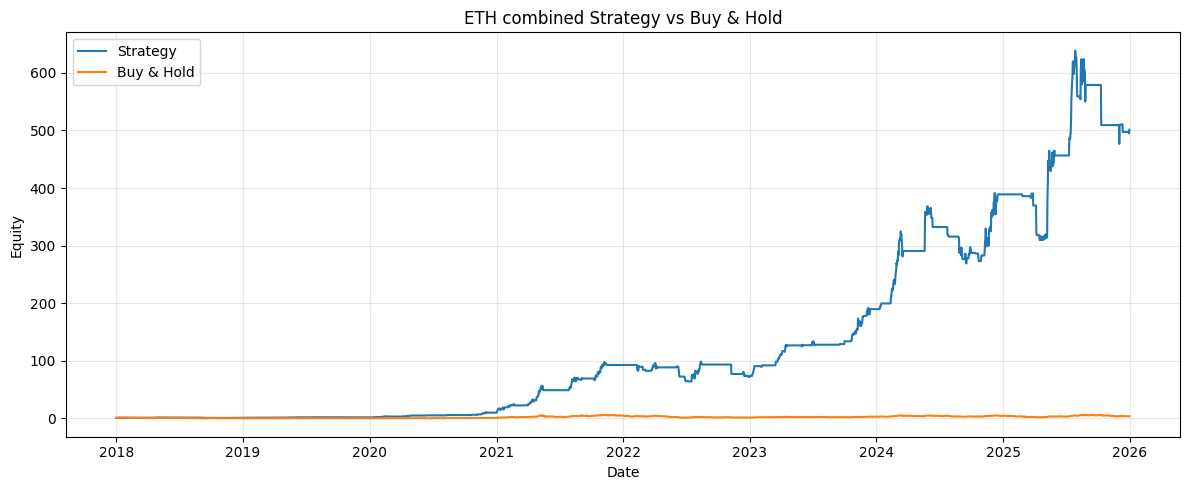

In [8]:
# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="ETH combined Strategy vs Buy & Hold")
plt.show()

#### btc


--- Final Strategy Performance ---
cumulative_pnl: 31.3301
average_daily_pnl: 0.0013
max_drawdown: -0.4762
annualised_return: 0.5440
sharpe_ratio_rf_3pct: 1.3600
daily_std_dev: 0.0178
annualised_volatility: 0.3396
exposure_rate: 0.2783
total_turnover: 226.0000
number_of_trades_total: 113.0000
number_of_complete_trades: 113.0000
win_rate: 0.5310
average_trade_return: 0.0384
median_trade_return: 0.0019
average_win_return: 0.1067
average_loss_return: -0.0389
profit_factor: 3.1035
payoff_ratio: 2.7414
expectancy_per_trade: 0.0384
best_trade: 0.6582
worst_trade: -0.2071
average_holding_periods: 7.1947
median_holding_periods: 4.0000
long_trades: 107.0000
short_trades: 6.0000


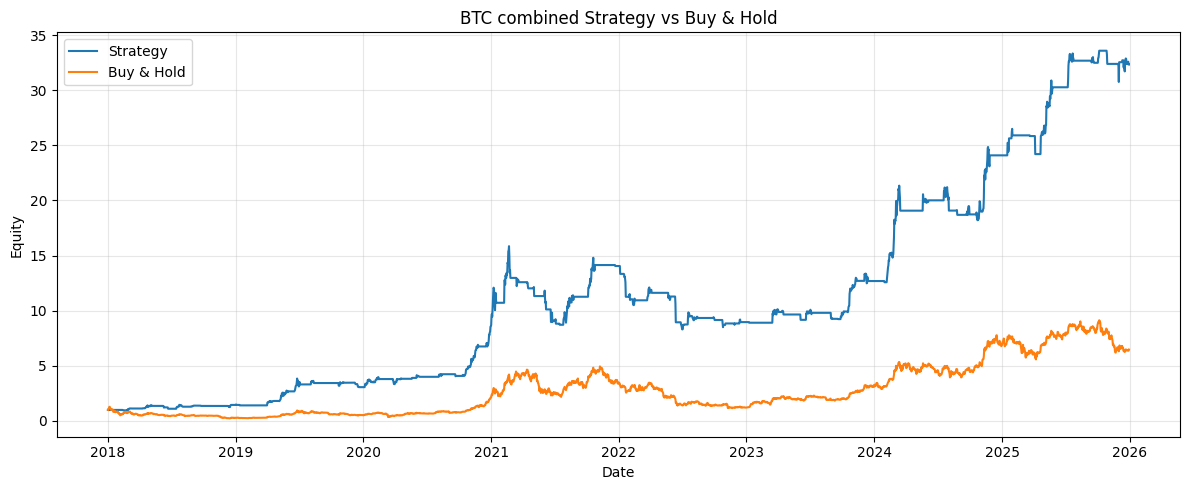

In [9]:
# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(btc_combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="BTC combined Strategy vs Buy & Hold")
plt.show()